Advanced Exploratory Data Analysis (EDA) and Feature Engineering on an E-Commerce Sales Dataset

## Objective

The objective of this project is to clean, analyze, and transform an e-commerce sales dataset using Exploratory Data Analysis (EDA) and Feature Engineering techniques. The cleaned dataset will be suitable for future machine learning applications.

Importing the Libraries

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Loading the Dataset

In [41]:
# Load the dataset
df = pd.read_csv("Dataset for Data Analytics - Sheet1.csv")


In [48]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,AveragePricePerItem
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,570.62
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,151.35
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,550.68
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,626.01


Exploring the Dataset

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [13]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [14]:
df.shape

(1200, 14)

In [15]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

Checking the Missing Values

In [45]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

Checking the Duplicate Rows

In [19]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.drop_duplicates(inplace=True)

Detecting the Outliers

Your numerical columns include:

Quantity
UnitPrice
ItemsInCart
TotalPrice

Boxplot

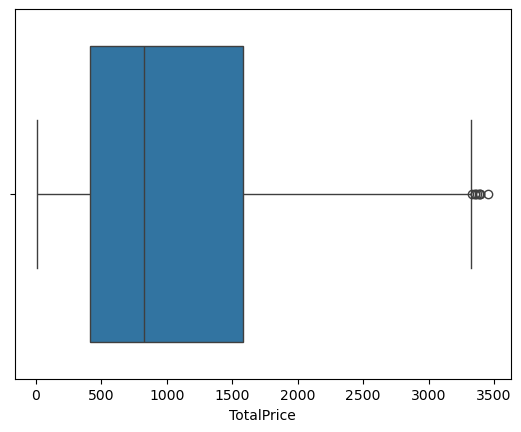

In [22]:
sns.boxplot(x=df["TotalPrice"])
plt.show()

Removing Outliers Using IQR

In [25]:
Q1 = df["TotalPrice"].quantile(0.25)

Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

df = df[(df["TotalPrice"] >= lower) &
        (df["TotalPrice"] <= upper)]

Exploratory Data Analysis (EDA)

Histogram

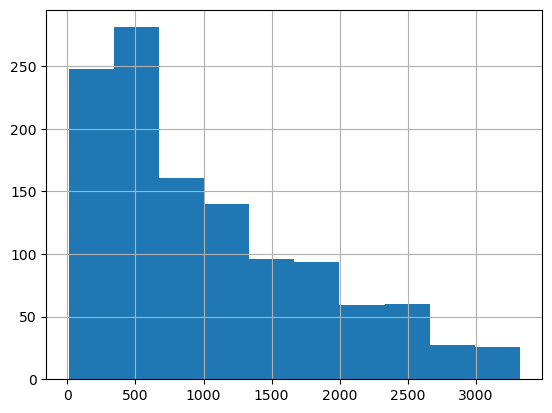

In [24]:
df["TotalPrice"].hist()
plt.show()

Correlation Heatmap

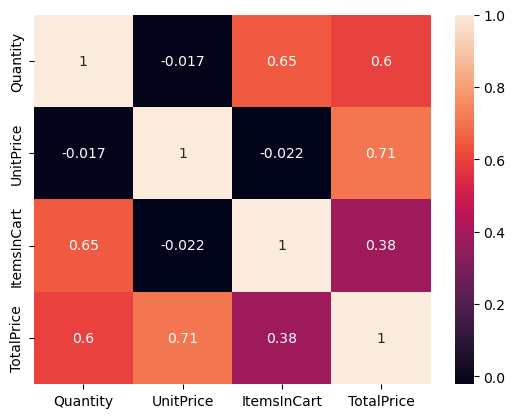

In [26]:
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True)

plt.show()

Payment Method Count

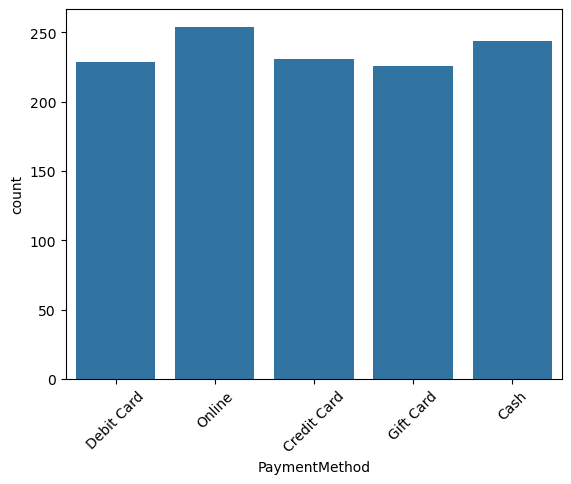

In [27]:
sns.countplot(data=df, x="PaymentMethod")
plt.xticks(rotation=45)
plt.show()

Order Status

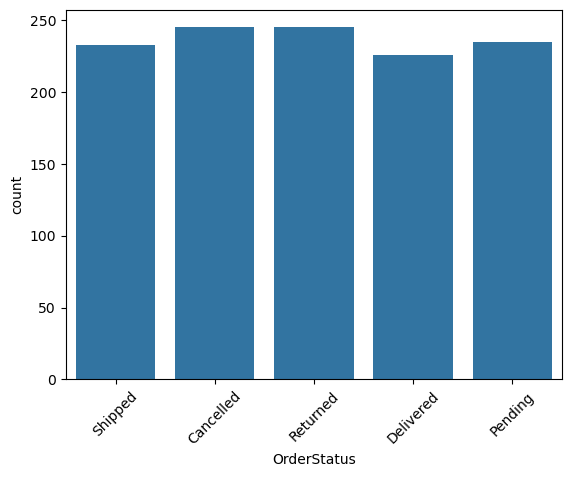

In [28]:
sns.countplot(data=df, x="OrderStatus")
plt.xticks(rotation=45)
plt.show()

Referral Source

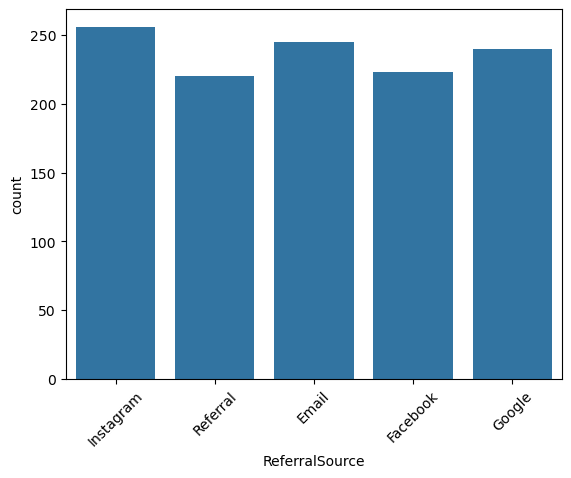

In [29]:
sns.countplot(data=df, x="ReferralSource")
plt.xticks(rotation=45)
plt.show()

Feature Engineering

Feature 1: Average Price Per Item

In [46]:
df["AveragePricePerItem"] = df["TotalPrice"] / df["Quantity"]

Feature 2: Order Size

In [31]:
df["OrderSize"] = np.where(df["Quantity"] >= 5,
                           "Large",
                           "Small")

Feature 3: Discount Applied

In [32]:
df["DiscountApplied"] = np.where(df["CouponCode"].notna(),
                                 1,
                                 0)

Feature 4: Month

In [33]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month_name()

Feature 5: Year

In [34]:
df["Year"] = df["Date"].dt.year

Saving the Cleaned Dataset

In [35]:
df.to_csv("cleaned_dataset.csv", index=False)

Verifying the Cleaned Dataset

In [36]:
cleaned_df = pd.read_csv("cleaned_dataset.csv")
cleaned_df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,AveragePricePerItem,OrderSize,DiscountApplied,Month,Year
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,570.62,Large,1,January,2023
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,151.35,Small,1,August,2024
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,550.68,Large,1,February,2024
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19,Small,1,October,2023
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,626.01,Small,1,May,2025


In [37]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1184 entries, 0 to 1183
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   OrderID              1184 non-null   object 
 1   Date                 1184 non-null   object 
 2   CustomerID           1184 non-null   object 
 3   Product              1184 non-null   object 
 4   Quantity             1184 non-null   int64  
 5   UnitPrice            1184 non-null   float64
 6   ShippingAddress      1184 non-null   object 
 7   PaymentMethod        1184 non-null   object 
 8   OrderStatus          1184 non-null   object 
 9   TrackingNumber       1184 non-null   object 
 10  ItemsInCart          1184 non-null   int64  
 11  CouponCode           878 non-null    object 
 12  ReferralSource       1184 non-null   object 
 13  TotalPrice           1184 non-null   float64
 14  AveragePricePerItem  1184 non-null   float64
 15  OrderSize            1184 non-null   o

Final Quality Checks

In [38]:
cleaned_df.isnull().sum()

OrderID                  0
Date                     0
CustomerID               0
Product                  0
Quantity                 0
UnitPrice                0
ShippingAddress          0
PaymentMethod            0
OrderStatus              0
TrackingNumber           0
ItemsInCart              0
CouponCode             306
ReferralSource           0
TotalPrice               0
AveragePricePerItem      0
OrderSize                0
DiscountApplied          0
Month                    0
Year                     0
dtype: int64

In [39]:
cleaned_df.duplicated().sum()

np.int64(0)

In [40]:
print(cleaned_df.shape)

(1184, 19)


Final Dataset

In [47]:
cleaned_df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,AveragePricePerItem,OrderSize,DiscountApplied,Month,Year
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,570.62,Large,1,January,2023
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,151.35,Small,1,August,2024
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,550.68,Large,1,February,2024
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19,Small,1,October,2023
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,626.01,Small,1,May,2025


# Final Quality Check

The cleaned dataset was verified after preprocessing.

Results:
- No missing values are present.
- No duplicate records are present.
- The dataset is clean and ready for machine learning applications.

# Conclusion

In this project, an e-commerce sales dataset was cleaned and analyzed using Python for machine learning.

The following tasks were completed:

- Imported and explored the dataset.
- Checked data types and summary statistics.
- Handled missing values using appropriate statistical methods.
- Removed duplicate records.
- Detected and treated outliers using the IQR method.
- Created new features such as AveragePricePerItem, OrderSize, and DiscountApplied.
- Performed Exploratory Data Analysis (EDA) using various visualizations.
- Saved the cleaned dataset for future machine learning tasks as cleaned_dataset.csv.

The final dataset is clean, consistent, and ready for predictive modeling and machine learning applications.